In [2]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

In [3]:
#load subject S2
with open("../data/WESAD/S2/S2.pkl", "rb") as file:
    data = pickle.load(file, encoding ='latin1')
    
data.keys()


C:\Users\PC\AppData\Local\Temp\ipykernel_3568\3041823821.py:3: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  data = pickle.load(file, encoding ='latin1')


dict_keys(['signal', 'label', 'subject'])

In [4]:
wrist_signals = data['signal']['wrist']
wrist_signals.keys()

dict_keys(['ACC', 'BVP', 'EDA', 'TEMP'])

In [5]:
type(wrist_signals['EDA'])
wrist_signals['EDA'].shape

(24316, 1)

In [6]:
wrist_signals['EDA'][:10] #show the first 10 samples, they are raw 
#skin conductance values 
#in microsiemens

array([[1.138257],
       [1.125444],
       [1.011405],
       [1.033188],
       [0.935807],
       [0.935708],
       [0.962616],
       [0.934426],
       [0.967741],
       [1.094593]])

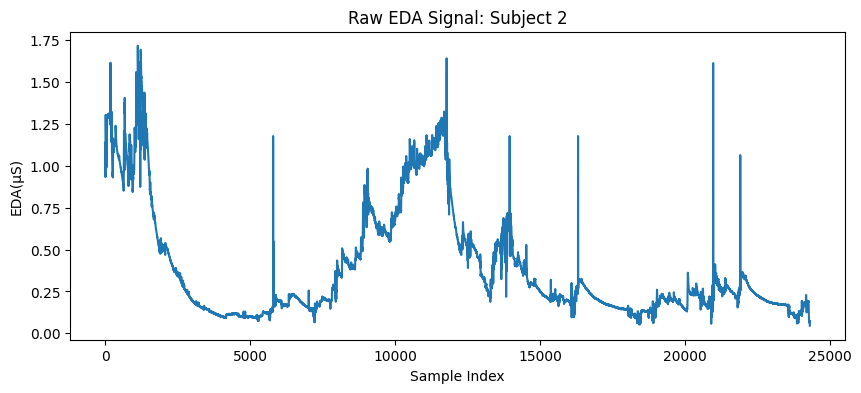

In [7]:
#visualizing EDA signal
eda = wrist_signals['EDA'] #Extract column vector

plt.figure(figsize=(10,4)) #Creates a new figure for plotting, with a width of 10 inches and height of 4 inches. 
#This controls how large the plot will appear.

#Plot EDA signal values against their index
#I have not specified an x-axis so matplotlib automatically uses sample index(0 to 2413) as x-axis
#X-axis = sample index; the time steps
#Y-axis = EDA values in microsiemens
plt.plot(eda)

#add title
plt.title("Raw EDA Signal: Subject 2")
#X-axis label
plt.xlabel("Sample Index")
#Label Y-axis
plt.ylabel("EDA(µS)")
#Display plot window to see graph
plt.show()

#Slow drifting baseline(tonic component)
#Small sharp bumps(phasic responses/ SCR)

In [8]:
data['label'].shape

(4255300,)

In [9]:
wrist_signals['BVP'].shape



(389056, 1)

In [10]:
wrist_signals['EDA'].shape

(24316, 1)

In [11]:

#Defining sampling rate and window 
#.flatten() converst shape to 1D array this is because feature calculation is easier on 1D arrays
eda = wrist_signals['EDA'].flatten()

#sampling rate
fs_eda = 4
window_seconds = 60
window_size = fs_eda * window_seconds

print("Window Size:", window_size)

Window Size: 240


In [12]:
#Creating Windows by segmenting the EDA signal into fixed sixed windows and storing those windows in a numpy array
#Initialize an empty list
windows = []

#Loop through the EDA signal in steps of window_size(240)
#So instead of sliding a sample at a time we jump 60 seconds at a time
#start is the begining index of each window
#range(start, stop, step) generates a sequence of numbers
#start =0 begin at index 0
#stop=len(eda) - windows_size: Go up to the last index where a full window can still fit
#step = window_size: jump forward by window size each time 
for start in range(0, len(eda) - window_size, window_size):
    end = start + window_size #end is the ending index
    window = eda[start:end] #slice the signal into chunks of length window_size 
    windows.append(window)

windows = np.array(windows)

print("Number of windows:", windows.shape[0])
print("Window Shape:", windows.shape[1])

Number of windows: 101
Window Shape: 240


In [13]:
#Inspect unique labels
labels = data['label']
np.unique(labels)#find all unique values in array labels

array([0, 1, 2, 3, 4, 6, 7], dtype=int32)

In [14]:
#USe NumPy to analyze the distribution of values in an array called labels
unique, counts = np.unique(labels, return_counts=True) #return_counts=True argument makes it return not only the unique values but also how many timee each one appears

#zip pairs each unique value (u) with its corresponding count (c)
for u, c in zip(unique, counts):

    #print each label and the number of times it appears in the dataset
    print(f"Label {u}: {c} samples")


Label 0: 2142701 samples
Label 1: 800800 samples
Label 2: 430500 samples
Label 3: 253400 samples
Label 4: 537599 samples
Label 6: 45500 samples
Label 7: 44800 samples


In [15]:
#Creating a filtered label mask for only classes we care about 
#Defining which labels are acceptable
valid_labels = [1,2,3]
#np.isin checks each element of labels to see if it belongs to valid_labels
#it returns a boolean arrat(True if the label is valid, False otherwise)
mask = np.isin(labels, valid_labels)

#use the boolean mask to select only valid entries
filtered_labels = labels[mask] #filtered_labels = [1,2,3]

#print how many labels remain after filtering
print("Total usable label samples:", len(filtered_labels))





Total usable label samples: 1484700


In [16]:
import numpy as np
import os

os.makedirs("../data/processed", exist_ok=True)
np.save("../data/processed/eda_windows_s2.npy", windows)
